In [1]:
include("plot_appendix.jl")

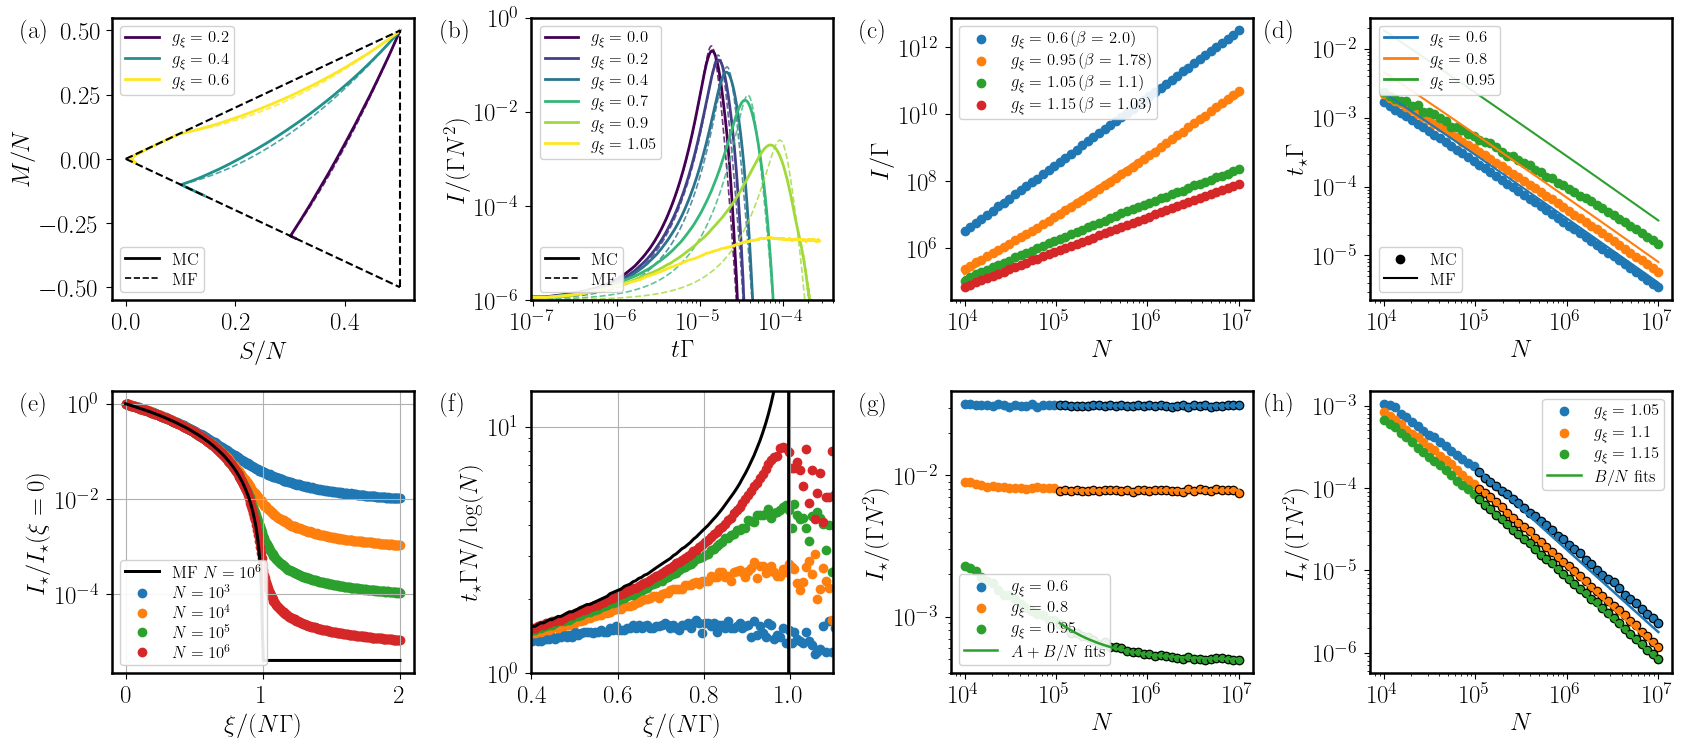

In [2]:
fig2a_file = "../plot_data/fig2a_data.jld2"
compare_file = "../plot_data/fig_compare_mc_mf_intensity.jld2"
scan_file = "../plot_data/dephasing_main_scan.jld2"
outfile = "../data/fig2.pdf"

W, H = latex_plot_setup(ratio=0.9, scale=1.8)

fig, axes = subplots(
    ncols = 4,
    nrows = 2,
    figsize = (4.0 * W, 2.0 * H)
)

plot_fig2a!(axes[1,1], load(fig2a_file)["data"])
plot_dephasing_panel_a!(axes[2,1], load(scan_file))
plot_compare_mc_mf_intensity!(axes[1,2], load(compare_file))
plot_dephasing_panel_b!(axes[2,2], load(scan_file))


datafile = joinpath(@__DIR__, "..", "plot_data", "dephasing_finiteN_scan.jld2")
d = load(datafile)


plot_dephasing_panel_d!(axes[1,3], d)
plot_dephasing_peak_time_panel!(axes[1,4], d)
plot_dephasing_panel_c_below_fit!(axes[2,3], d; which = 2)
plot_dephasing_panel_c_above_fit!(axes[2,4], d; which = 1)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[1,3].text(-0.3, 1.0, "(c)", transform=axes[1,3].transAxes, va="top")
axes[2,4].text(-0.35, 1.0, "(d)", transform=axes[1,4].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(e)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(f)", transform=axes[2,2].transAxes, va="top")
axes[2,3].text(-0.3, 1.0, "(g)", transform=axes[2,3].transAxes, va="top")
axes[2,4].text(-0.35, 1.0, "(h)", transform=axes[2,4].transAxes, va="top")
axes[1,2].set_ylim(bottom = 1e-6)

savefig("../data/figS5.pdf", bbox_inches = "tight")

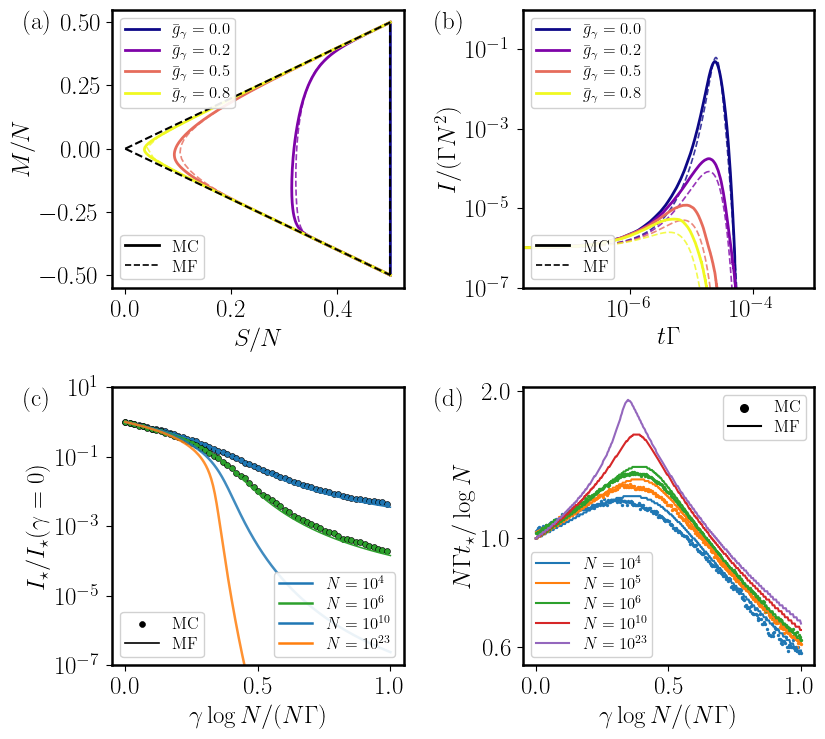

: 

In [ ]:
traj_file = "../plot_data/fig_trajectories_gamma.jld2"
intensity_file = "../plot_data/fig_compare_mc_mf_intensity_gamma.jld2"
sharp_file = "../plot_data/spont_sharpening_data.jld2"
collapse_file = "../plot_data/spont_collapse_data.jld2"
times_file = "../plot_data/times_spont_meanfield.jld2"

data_traj = namedtuple_to_dict(load(traj_file)["data"])
data_int = load(intensity_file)
data_sharp = load(sharp_file)
data_coll = load(collapse_file)
data_mc = load(collapse_file)
data_mf = load(times_file)

w, h = latex_plot_setup(ratio = 0.9, scale = 1.8)
fig, axes = subplots(ncols = 2, nrows = 2, figsize = (2w, 2h))

# (a): previous (a)
plot_fig2b_gamma!(axes[1, 1], data_traj)

# (b): previous (d)
plot_compare_mc_mf_intensity_gamma!(axes[1, 2], data_int)
axes[1, 2].set_ylim(bottom = 1e-7)
axes[1, 2].set_xlim(right = 1e-3)

# (c): previous (b)
plot_spont_scaling_single!(axes[2, 1], data_sharp, data_coll)

# (d): previous (f)
plot_spont_peak_times!(axes[2, 2], data_mc, data_mf)

axes[1, 1].text(-0.3, 1.0, "(a)", transform = axes[1, 1].transAxes, va = "top")
axes[1, 2].text(-0.3, 1.0, "(b)", transform = axes[1, 2].transAxes, va = "top")
axes[2, 1].text(-0.3, 1.0, "(c)", transform = axes[2, 1].transAxes, va = "top")
axes[2, 2].text(-0.3, 1.0, "(d)", transform = axes[2, 2].transAxes, va = "top")

tight_layout()
savefig("../data/small_spontaneous.pdf", bbox_inches = "tight")